# From Classical Limits to Quantum Power: Deutsch’s Two-Qubit Solution

## Introduction

We can define a quantum algorithm as a sequence of quantum operations applied in a particular order to solve problems by harnessing the unique principles of quantum mechanics. Unlike classical algorithms that use bits—restricted to values of either 0 or 1—quantum algorithms use qubits, which can exist in a superposition of both states simultaneously. This allows quantum systems to process multiple possibilities in parallel, offering potential advantages over classical approaches.

In this chapter, we will explore one of the simplest examples of a quantum algorithm that highlights how quantum computing can outperform classical methods: the *Deutsch algorithm*. While it doesn’t have direct practical applications, it serves as a foundational example for understanding how quantum features like superposition and interference can be leveraged to solve problems more efficiently. The Deutsch algorithm is often used as an entry point into quantum computing, illustrating the fundamental principles that power more complex quantum algorithms.

## Deutsch Problem

Deutsch’s problem is one of the simplest examples in quantum computing that highlights how quantum algorithms can outperform classical ones. Though it involves a very basic setup, it introduces key concepts like quantum parallelism and interference, which are foundational to many quantum algorithms.

### Problem Statement

Imagine you have a mysterious function  $f(x)$  that takes a single bit  $x$  as input. Since the input is just one bit, it can be either  $0$  or  $1$ . The function  $f(x)$  produces an output of either  $0$  or  $1$  for each input provided. However, the internal mechanism of the function remains unknown to you. You can only interact with it by querying, i.e. by supplying an input and observing the corresponding output.

In many contexts, such a function is referred to as an *oracle*. An oracle is essentially a black-box (function or subroutine) that provides specific information about its behavior without disclosing its internal workings. It serves as a tool that the system can query to gain insights or verify certain conditions.
For simplicity, we will continue using the term function in this context

You are told that the function is either *constant* or *balanced*. A constant function means that it gives the same output for both inputs, i.e. $f(0) = f(1)$. A balanced funtion means that it gives different outputs for the two inputs, i.e. $f(0) \neq f(1)$.

The goal is to *determine whether the function is constant or balanced with the least number of queries*.

Using classical computers, to be sure whether the function is constant or balanced, you must check both inputs. You must load $0$ as the input and record $f(0)$ and separately, load $x=1$ and evaluate $f(1)$.
Only by seeing both results you can confidently determine if the function is *constant* or *balanced*. Therefore, minimum number of queries required for classical computers is two. 
Deutsch's algorithm is supposed to outperform classical counterpart. This means that using Desutsch's solution implemented in a quantum circuit, one can determine whethere $f(x)$ is constant or balanced with only **one query**.

### Set up

Before we start with the solution using quantum algorithms, we briefly explain how to set up an algorithm. 
At its core, a quantum algorithm follows these basic steps:
- **Initialize qubits**: Start with qubits in a known state (usually $\ket{0}$ for all qubits). If you need $\ket{1}$ for certain qubits, use $X$ to flip the initial state.
- **Create Superposition**: Apply gates such as the Hadamard gate $H$ to place qubits into superposition, allowing the algorithm to explore multiple possibilities simultaneously. Whether this step is applied depends on the specific problem being addressed. In some cases, certain problems may bypass this step entirely.
- **Apply Quantum Operations**: Use a sequence of quantum gates (like $X$, $H$, or $C_{10}$) to manipulate the qubits and encode the problem into their states.
- **Leverage Quantum Phenomena**: Quantum algorithms exploit principles like interference (where certain paths reinforce or cancel each other) and entanglement (where qubits become correlated) to guide the system toward the correct solution.
- **Measure the Qubits**: Finally, measure the qubits to collapse them into classical bits. The outcome reveals the solution or helps in approximating it.


### Deutsch Algorithm

Now let's start with Deutsch's solution. In this section we will focus on the solution with only two qubits but the solution is extendible to a system with mutiple qubits (The Deutsch-Jozsa algorithm). Moreover, we try to associate the solution to the steps we have proposed above. 

1. **Initialize qubits**: The algorithm uses two qubits:
- The input qubit ( $\ket{x}$ ): initially set to  $\ket{0}$
- An auxiliary qubit ( $\ket{y}$ ): initially set to $\ket{1}$. First, we will load $y$ with $\ket{0}$ and then we will apply $X \ket{y}$.

After this step the initial state of the whole system is: $\ket{x}\ket{y} = \ket{0}\ket{1} = \ket{01}$

2. **Create Superpositions**: Applying a Hadamard gate $H$ to each qubit separately will result in:

- $H\ket{0} = \frac{1}{\sqrt 2}(\ket{0} + \ket{1})$ , for $\ket{x}$
- $H\ket{1} = \frac{1}{\sqrt 2}(\ket{0} - \ket{1})$ , for $\ket{y}$, after applying $X$.

In order to see what is the state of the whole system, we can apply two $H$s to $\ket{xy}$ which will result in:
$
H_1H_0\ket{xy} = H_1H_0\ket{01} = (H_1\ket{0})(H_0\ket{1}) = \frac{1}{2}(\ket{00}-\ket{01}+\ket{10}-\ket{11})
$

The system is now in a superposition of all possible inputs.

3. **Apply Quantum Operations**: In our context here, the quantum operation of our interest is the function $f(x)$. Let's assume that the function $f$ on input $\ket{x}$ is applicable through a unitary transformation (matrix) represented as $U_f$. Applying $U_f$ on our two qubit system will result in:

$
U_f\ket{x}\ket{y} = \ket{x}\ket{y \oplus f(x)}
$

**Note:** A section titled **Solution Design** below explains *why this formula holds and how it is derived*. If your curiosity about the design of the formula prevents you from continuing with the rest of this section, we recommend reading **Solution Design** first. Otherwise, for now, you can accept the formula as given and focus on understanding how the algorithm works. You can return to **Solution Design** later to explore the reasoning behind it.

Remember that in our setup $y$ is the auxiliary qubit to store the output. The qubit $\ket{y}$ is used to store the result of $f(x)$ in a way that maintains the reversibility required in quantum computing. The state $\ket{y \oplus f(x)}$ represents that applying $f(x)$ flips the state of the auxiliary qubit $\ket{y}$ if and only if $f(x)=1$. 


Let's apply $U_f$ to our prepared state:

$
U_f (\frac{1}{2}(\ket{00}-\ket{01}+\ket{10}-\ket{11})) = 
\frac{1}{2} (U_f \ket{00} - U_f \ket{01} + U_f \ket{10} - U_f \ket{11}) = 
$

$
\frac{1}{2} ( \ket{0}\ket{0 \oplus f(0)} - \ket{0}\ket{1 \oplus f(0)} + \ket{1}\ket{0 \oplus f(1)} - \ket{1}\ket{1 \oplus f(1)}) = \\
\frac{1}{2} (\ket{0}\ket{f(0)} - \ket{0}\ket{1 \oplus f(0)} + \ket{1}\ket{f(1)} - \ket{1}\ket{1 \oplus f(1)})
$

The final result after applying $\oplus$ will be:

$
\frac{1}{2} (\ket{0}\ket{f(0)} - \ket{0}\ket{\neg f(0)} + \ket{1}\ket{f(1)} - \ket{1}\ket{\neg f(1)})
$

1. **Leverage Quantum Phenomena**: We need to evaluate and symplify the final state. Let’s look at two possible cases:

Case 1: $f(x)$ is constant. This means $f(0)=f(1)$ and $\neg f(0) = \neg f(1)$. In this case our state will be:

- $f(0)=0 : \frac{1}{2} (\ket{0}\ket{0} - \ket{0}\ket{1} + \ket{1}\ket{0} - \ket{1}\ket{1}) $ This is the superposition of $\ket{01}$.
- $f(0)=1 : \frac{1}{2} (\ket{0}\ket{1} - \ket{0}\ket{0} + \ket{1}\ket{1} - \ket{1}\ket{0}) $ This is the superposition of $-\ket{01}$.
 
Case 2: $f(x)$ is balanced. This means $f(0) \neq f(1)$ or $f(0) = \neg f(1)$, $f(1) = \neg f(0)$. In this case our state will be:

- $f(0)=0 : \frac{1}{2} (\ket{0}\ket{0} - \ket{0}\ket{1} + \ket{1}\ket{1} - \ket{1}\ket{0}) $ This is the superposition of $\ket{11}$.
- $f(0)=1 : \frac{1}{2} (\ket{0}\ket{1} - \ket{0}\ket{0} + \ket{1}\ket{0} - \ket{1}\ket{1}) $ This is the superposition of $-\ket{11}$.

The evaluation is revealing something interesting. When the function $f(x)$ is constant the whole system is in a superposition that can be factored based on two qubits $\ket{01}$. Similarly when $f(x)$ is balanced the whole system is in a superposition that can be writen as $\ket{11}$. This means that **the value of $\ket{x}$ can reveal some information about $f(x)$**. We can apply another $H$ to each qubit to evaluate the final value. We apply another two $H$'s to prepare the qubits for measurements.

Case 1: $f(x)$ is constant.

- $f(0)=0 : HH(\frac{1}{2} (\ket{0}\ket{0} - \ket{0}\ket{1} + \ket{1}\ket{0} - \ket{1}\ket{1})) = \ket{01}$
- $f(0)=1 : HH(\frac{1}{2} (\ket{0}\ket{1} - \ket{0}\ket{0} + \ket{1}\ket{1} - \ket{1}\ket{0})) = -\ket{01}$.
 
Case 2: $f(x)$ is balanced.

- $f(0)=0 : HH(\frac{1}{2} (\ket{0}\ket{0} - \ket{0}\ket{1} + \ket{1}\ket{1} - \ket{1}\ket{0})) = \ket{11} $.
- $f(0)=1 : HH(\frac{1}{2} (\ket{0}\ket{1} - \ket{0}\ket{0} + \ket{1}\ket{0} - \ket{1}\ket{1})) = -\ket{11} $.

5. **Measure the Qubits**: In this step, the values of $ \ket{x} $ and $ \ket{y} $ can be measured. In the Deutsch problem, the negative signs in terms like $ -\ket{01} $ and $ -\ket{11} $ can be disregarded, as they have no effect on the measurement outcomes. Additionally, $ \ket{y} $ consistently collapses to $ \ket{1} $ in all cases, providing no useful information for determining the nature of $ f(x) $. Therefore, the focus shifts solely to the value of $ \ket{x} $, which reveals whether $ f(x) $ is constant or balanced.
Therefore, **by measuring the qubit $\ket{x}$, we can determine whether $f(x)$ is constant or balanced. If the measurement result is $\ket{0}$, we conclude that $f(x)$ is a *constant* function. If the result is $\ket{1}$, we conclude that $f(x)$ is a *balanced* function.**

#### The algorithm

What we have described in details so far about Deutsch algorithm, can be summarzied and rewritten as:

*Initialize both $\ket{x}$ and $\ket{y}$ to $\ket{0}$. Negate $\ket{y}$, put both qubits into superposition, apply $U_f$, take the qubits out of superposition, and finally measure $\ket{x}$.*

Here is the composition of the operations in mathematical form:

$
HH(U_f(HH(\ket{x}(X\ket{y}))))
$ , given both qubits are initialized with $\ket{0}$




#### Solution Design

Rather than presenting $U_f\ket{x}\ket{y} = \ket{x}\ket{y \oplus f(x)}$ as a given, it is more instructive to put ourselves in the position of the person designing the circuit. We simply want a quantum operation that "computes $f$", and we let the constraints of quantum mechanics narrow our options until only one natural form survives.

- **Attempt 1: the obvious map $\ket{x} \to \ket{f(x)}$.**
The first thing anyone would try is to build a gate that takes the input straight to the output, $\ket{x} \to \ket{f(x)}$. But as we discussed before every quantum gate is a unitary. This means that every quantum gate must be *reversible*, i.e. from the output we must always be able to recover the input. This map fails that test. If $f$ is constant, say $f(0) = f(1) = 0$, then

$$
\ket{0} \to \ket{0}, \qquad \ket{1} \to \ket{0},
$$

and both inputs collapse onto $\ket{0}$. Given the output $\ket{0}$ we cannot tell which $x$ produced it because information has been destroyed, so no unitary can implement this map. The lesson: **we are not allowed to discard the input.**

- **Attempt 2: keep the input, add a register for the answer.**
If we must not lose $x$, then $\ket{x}$ has to survive the operation unchanged. But then the result $f(x)$ has nowhere to go. So we are led to introduce a *second* qubit $\ket{y}$ (a dedicated auxiliary / output register) and look for an operation of the shape

$$
\ket{x}\ket{y} \;\longrightarrow\; \ket{x}\,\ket{\,?\,}.
$$

The input register carries $x$ through untouched; the question is only what to write into the second register.

- **Attempt 3: how do we deposit $f(x)$ reversibly?**
The tempting choice is to overwrite $y$ with the answer, $\ket{x}\ket{y} \to \ket{x}\ket{f(x)}$. But overwriting throws away whatever was in $y$ — the same irreversibility problem, one register over. What we really want is to *combine* the current value $y$ with $f(x)$ in a way we can always undo. On a single bit, the reversible way to add is addition modulo 2, i.e. the XOR operation $\oplus$. That gives

$$
U_f:\ \ket{x}\ket{y} \;\longrightarrow\; \ket{x}\ket{y \oplus f(x)}
$$

Reading off what this does to the target:

- $f(x) = 0: \quad y \oplus 0 = y$ i.e. target unchanged
- $f(x) = 1: \quad y \oplus 1 = \bar{y}$ i.e. target flipped ($\ket{0} \leftrightarrow \ket{1}$)

So $U_f$ flips $y$ precisely when $f(x) = 1$. This can be interpreted as a controlled operation with $f(x)$ as the control.

**Why this choice works.**
XOR is its own inverse, which is exactly the property we were hunting for. Applying $U_f$ twice returns the system to where it started:

$
U_f \ket{x}\ket{y} = \ket{x}\ket{y \oplus f(x)} 
$

$
U_f \ket{x}\ket{y \oplus f(x) \oplus f(x)} = \ket{x}\ket{y \oplus f(x) \oplus f(x)}=\ket{x}\ket{y}
$ since $f(x) \oplus f(x) = 0$

Hence $U_f^2 = I$: the operation is reversible and therefore a legitimate unitary gate. 

The three attempts to design a quantum solution to the Deutsch problem show how each constraint we encountered shaped the final solution. In this sense, the form of $U_f$ was not simply guessed; rather, it was forced by the requirements of the problem.

## Program

In this section we will implement the Deutsch algorithm in qiskit. First, we will implement the solution studied above with only two qubits.  
Before, implementing the full algorithm, we need to practice how to implement the oracle (or the function $f(x)$). There are four possible functions that can be used to implement the oracle:

$f(0)$ | $f(1)$ | type
----|---- | ---
$0$ | $0$ | constant
$0$ | $1$ | balanced
$1$ | $0$ | balanced
$1$ | $1$ | constant

The functions implemented below provides four possible circuits:

In [2]:
from qiskit import QuantumCircuit

def oracle_00(circuit):     #implements function f(0)=0 and f(1)=0
    return

def oracle_01(circuit):     #implements function f(0)=0 and f(1)=1
    circuit.cx(0,1)
    return

def oracle_10(circuit):     #implements function f(0)=1 and f(1)=0
    circuit.x(1)
    circuit.cx(0,1)
    return

def oracle_11(circuit):     #implements function f(0)=1 and f(1)=1
    circuit.x(1)
    return

oracles = [oracle_00 , oracle_01 , oracle_10 , oracle_11]

for orc in oracles:
    qc = QuantumCircuit(2,0) # Initialize qubits: 2 qubits and no classical bits (we don't measure any qubit yet)
    qc.barrier() # Start of the Oracle: The barrier only separates the start / end of the oracle (subroutine) from the rest of the algorithm
    orc(qc)
    qc.barrier() # End of the Oracle: The barrier only separates the start / end of the oracle (subroutine) from the rest of the algorithm
    print(orc.__name__)
    print(qc)
    print('---------------------------')

oracle_00
      ░  ░ 
q_0: ─░──░─
      ░  ░ 
q_1: ─░──░─
      ░  ░ 
---------------------------
oracle_01
      ░       ░ 
q_0: ─░───■───░─
      ░ ┌─┴─┐ ░ 
q_1: ─░─┤ X ├─░─
      ░ └───┘ ░ 
---------------------------
oracle_10
      ░            ░ 
q_0: ─░────────■───░─
      ░ ┌───┐┌─┴─┐ ░ 
q_1: ─░─┤ X ├┤ X ├─░─
      ░ └───┘└───┘ ░ 
---------------------------
oracle_11
      ░       ░ 
q_0: ─░───────░─
      ░ ┌───┐ ░ 
q_1: ─░─┤ X ├─░─
      ░ └───┘ ░ 
---------------------------


In [3]:
from qiskit import transpile
from qiskit_aer import AerSimulator

def Deutsch_Circuit(deutch_qc, oracle):
    deutch_qc.x(1) # The auxiliary bit (y) must be set to 1.
    deutch_qc.h(0) # input in superposition
    deutch_qc.h(1) # auxiliary in superposition
    deutch_qc.barrier()
    oracle(deutch_qc) # query oracle
    deutch_qc.barrier()
    deutch_qc.h(0) # transform input into basis state
    deutch_qc.h(1) # transform auxiliary into basis state
    deutch_qc.measure(0, 0)  # Measure qubit 0 and store in classical bit 0
#    deutch_qc.measure(1, 1)  # Measure qubit 1 and store in classical bit 1


def Deutch_Run(circuit):
    simulator = AerSimulator()
    compiled_circuit = transpile(circuit, simulator)
    result = simulator.run(compiled_circuit, shots=1024).result()
    return result

Measurement results: {'0': 1024}


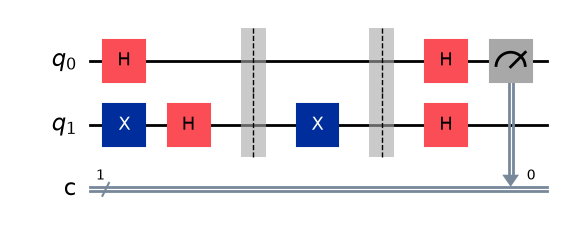

In [8]:
# Experiment 1: Constant function

# Create a 2-qubit and 1-cbit circuit: 1-cbit because we only need to measure input x
qc = QuantumCircuit(2,1)
Deutsch_Circuit(qc,oracle_11)
result = Deutch_Run(qc)

# Get the counts (frequency of measurement outcomes)
counts = result.get_counts()
# Print the measurement results
print("Measurement results:", counts)
qc.draw("mpl")  

Measurement results: {'1': 1024}


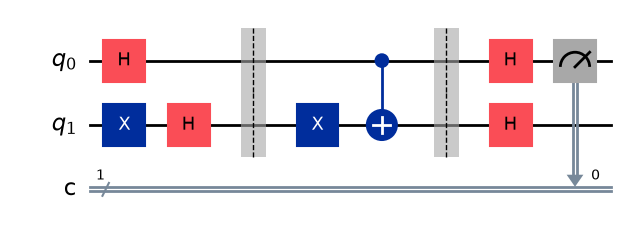

In [7]:
# Experiment 2: Balanced function

# Create a 2-qubit and 1-cbit circuit: 1-cbit because we only need to measure input x
qc = QuantumCircuit(2,1)
Deutsch_Circuit(qc,oracle_10)
result = Deutch_Run(qc)

# Get the counts (frequency of measurement outcomes)
counts = result.get_counts()
# Print the measurement results
print("Measurement results:", counts)
qc.draw("mpl") 

## Summary

This part of the tutorial introduced our first quantum algorithm. We defined the Deutsch problem and showed how quantum registers and quantum operations work together to solve it using fewer queries than any classical approach requires. The two-qubit case served as a concrete example, making it possible to follow exactly where the advantage comes from.

The algorithm has little practical value on its own, but its educational value is considerable. It provides the smallest setting in which the distinctive features of quantum computing can be observed directly, which makes it an ideal starting point for building intuition before moving on to more capable algorithms.

Scaled up to many qubits, the same idea becomes the Deutsch–Jozsa algorithm, which is the subject of the next tutorial. Beyond extending the algorithm itself, that discussion will focus on two fundamental concepts that underlie much of quantum computing: phase kickback and quantum parallelism.